In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.io
from scipy.optimize import nnls
import os


In [2]:
def generate_sparse_spectrum(number_of_spikes):
    x = np.arange(1500)
    spectrum = np.zeros(1500)
    for _ in range(number_of_spikes):
        center = random.uniform(0, 1500)
        width = random.uniform(0.5, 2.0)
        intensity = random.random()
        spectrum += intensity * np.exp(-((x - center)**2) / (2 * width**2))
    return spectrum / np.max(spectrum)

def generate_narrow_absorption(number_of_spikes):
    x = np.arange(1500)
    spectrum = np.ones(1500)
    for _ in range(number_of_spikes):
        center = random.uniform(0, 1500)
        width = random.uniform(0.5, 2.0)
        intensity = random.random()
        spectrum -= intensity * np.exp(-((x - center)**2) / (2 * width**2))
    return np.clip(spectrum, 0, 1)

def broad_curve(x, x0, gamma, I_peak):
    return I_peak / (1 + ((x - x0) / gamma) ** 2)

def generate_broad_emission(number_of_peaks):
    spectrum = np.zeros(1500)
    spectrum_clean = np.arange(1500)
    for _ in range(number_of_peaks):
        center = random.uniform(0,1500)
        width = random.uniform(5,700)
        height = random.uniform(0.1,1.0)
        spectrum += broad_curve(spectrum_clean, center, width, height)
    return spectrum / np.max(spectrum)

def generate_broad_absorption(number_of_peaks):
    return 1.0 - generate_broad_emission(number_of_peaks)


In [3]:
# Load calibration matrix and define the noisy-measurement simulator
calibration_matrix = scipy.io.loadmat(
    "/Users/jatinvirmatharoo/Documents/Spectrometer URA/transmission_matrices/Matrix_calabration_Dis7.mat"
)['mat2']

def simulate_measurement(spectrum, T, snr_db=30):
    measurement = np.dot(T, spectrum)
    signal_power = np.mean(measurement ** 2)
    noise_level = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_level), measurement.shape)
    return measurement + noise


In [4]:
# Generate the 3000 synthetic spectra + sensor measurements.
# Idempotent: if data files already exist, just load them. Otherwise generate fresh
# with seed=42 and save. This way alpha sweeps in the next cell don't redo this step.

spectra_files = [
    "data/X_train_np.npy",
    "data/y_train_np.npy",
    "data/labels_list.npy",
]

if all(os.path.exists(f) for f in spectra_files):
    print("Spectra files already exist - loading from disk.")
    X_train_np = np.load("data/X_train_np.npy")
    y_train_np = np.load("data/y_train_np.npy")
    labels_list = np.load("data/labels_list.npy", allow_pickle=True)
else:
    print("Generating 3000 synthetic samples...")
    random.seed(42)
    np.random.seed(42)

    X_train_list, y_train_list, labels_list = [], [], []
    for _ in range(3000):
        spectrum_generator = random.choice([
            generate_sparse_spectrum, generate_broad_emission,
            generate_narrow_absorption, generate_broad_absorption,
        ])
        labels_list.append(spectrum_generator.__name__)
        spectrum = spectrum_generator(random.randint(1, 10))
        snr_db = random.choice([30, 40, 50])
        measurement = simulate_measurement(spectrum, calibration_matrix, snr_db)
        X_train_list.append(measurement)
        y_train_list.append(spectrum)

    X_train_np = np.array(X_train_list)
    y_train_np = np.array(y_train_list)
    labels_list = np.array(labels_list)

    np.save("data/X_train_np.npy", X_train_np)
    np.save("data/y_train_np.npy", y_train_np)
    np.save("data/labels_list.npy", labels_list)
    print("Saved.")

print(f"X_train_np shape:  {X_train_np.shape}")
print(f"y_train_np shape:  {y_train_np.shape}")
print(f"labels_list shape: {labels_list.shape}")


Spectra files already exist - loading from disk.
X_train_np shape:  (3000, 25)
y_train_np shape:  (3000, 1500)
labels_list shape: (3000,)


In [ ]:
# Reg solver rough draft generation.
# Tunables at the top so you can sweep alpha or swap solvers without changing anything else.
# Each run saves to its own file so the existing baseline (X_train_rough.npy) is untouched.

from joblib import Parallel, delayed

# --- Knobs ---
SOLVER = "lsq_linear"  # "nnls"       = NNLS (active set, non-negative)        - slow, parallel
                       # "lstsq"      = unconstrained LS                       - fast, vectorized
                       # "lsq_linear" = bounded LS (active set, 0<=x<=1)       - slow, parallel  <- Option 1
ALPHA = 50000          # smoothness regularization weight
BROAD_ONLY = True      # only run on broad samples (~1479 vs 3000)
N_JOBS = -1            # only used by per-sample solvers

# --- Output filename encodes the experiment ---
suffix = f"broad_{SOLVER}_alpha{ALPHA}" if BROAD_ONLY else f"{SOLVER}_alpha{ALPHA}"
output_path = f"data/X_train_rough_{suffix}.npy"
indices_path = f"data/X_train_rough_{suffix}_indices.npy"

# --- Build augmented system (same for all solvers) ---
def build_L(n):
    L = np.zeros((n - 1, n))
    for i in range(n - 1):
        L[i, i] = -1
        L[i, i + 1] = 1
    return L

T = calibration_matrix
L = build_L(1500)
T_aug = np.vstack([T, np.sqrt(ALPHA) * L])

# --- Pick samples ---
if BROAD_ONLY:
    broad_types = {"generate_broad_emission", "generate_broad_absorption"}
    mask = np.array([lbl in broad_types for lbl in labels_list])
    indices = np.where(mask)[0]
else:
    indices = np.arange(len(X_train_np))

print(f"Solver={SOLVER}, alpha={ALPHA}, samples={len(indices)}")
print(f"Output: {output_path}")

# --- Solve ---
if SOLVER == "nnls":
    from scipy.optimize import nnls
    def solve_one(measurement, T_aug):
        y_aug = np.concatenate([measurement, np.zeros(1499)])
        x, _ = nnls(T_aug, y_aug)
        return x
    results = Parallel(n_jobs=N_JOBS, verbose=10)(
        delayed(solve_one)(X_train_np[i], T_aug) for i in indices
    )
    X_rough = np.array(results)

elif SOLVER == "lstsq":
    # Unconstrained LS: solve all samples at once via batched RHS.
    measurements = X_train_np[indices].T            # (25, n_broad)
    zeros_pad = np.zeros((1499, len(indices)))      # (1499, n_broad)
    y_augs = np.vstack([measurements, zeros_pad])   # (1524, n_broad)
    sol, *_ = np.linalg.lstsq(T_aug, y_augs, rcond=None)
    X_rough = sol.T

elif SOLVER == "lsq_linear":
    # Bounded LS via BVLS (active-set, like NNLS but with upper bound too).
    # Should run in roughly NNLS time, much faster than the default 'trf' method.
    from scipy.optimize import lsq_linear
    def solve_one(measurement, T_aug):
        y_aug = np.concatenate([measurement, np.zeros(1499)])
        result = lsq_linear(T_aug, y_aug, bounds=(0, 1), method='bvls')
        return result.x
    results = Parallel(n_jobs=N_JOBS, verbose=10)(
        delayed(solve_one)(X_train_np[i], T_aug) for i in indices
    )
    X_rough = np.array(results)

else:
    raise ValueError(f"Unknown SOLVER: {SOLVER}")

np.save(output_path, X_rough)
np.save(indices_path, indices)
print(f"Done. Saved {X_rough.shape} -> {output_path}")
print(f"Range of X_rough: [{X_rough.min():.3f}, {X_rough.max():.3f}]")


In [ ]:
# Sanity check: visualize a few rough drafts vs ground truth
# and report mean MSE of the rough drafts (input quality metric).
wavelengths = np.linspace(1550, 1565, 1500)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
preview_js = [0, 50, 200, 500]
for ax, j in zip(axes.flatten(), preview_js):
    if j >= len(indices):
        continue
    i = indices[j]
    ax.plot(wavelengths, y_train_np[i], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_rough[j], label=f"NNLS alpha={ALPHA}", color="blue", alpha=0.7)
    ax.set_title(f"Sample {i} ({labels_list[i].replace('generate_', '')})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mse_input = np.mean((X_rough - y_train_np[indices]) ** 2)
print(f"Mean MSE of rough drafts vs ground truth (alpha={ALPHA}): {mse_input:.6f}")


Old data/X_train_rough.npy (broad subset):  MSE = 0.078262
  range: [0.000, 1.000]

New alpha=50000 generation:                MSE = 0.179778
  range: [0.000, 9.142]

If old range is [0, 1] exactly, it was clipped.


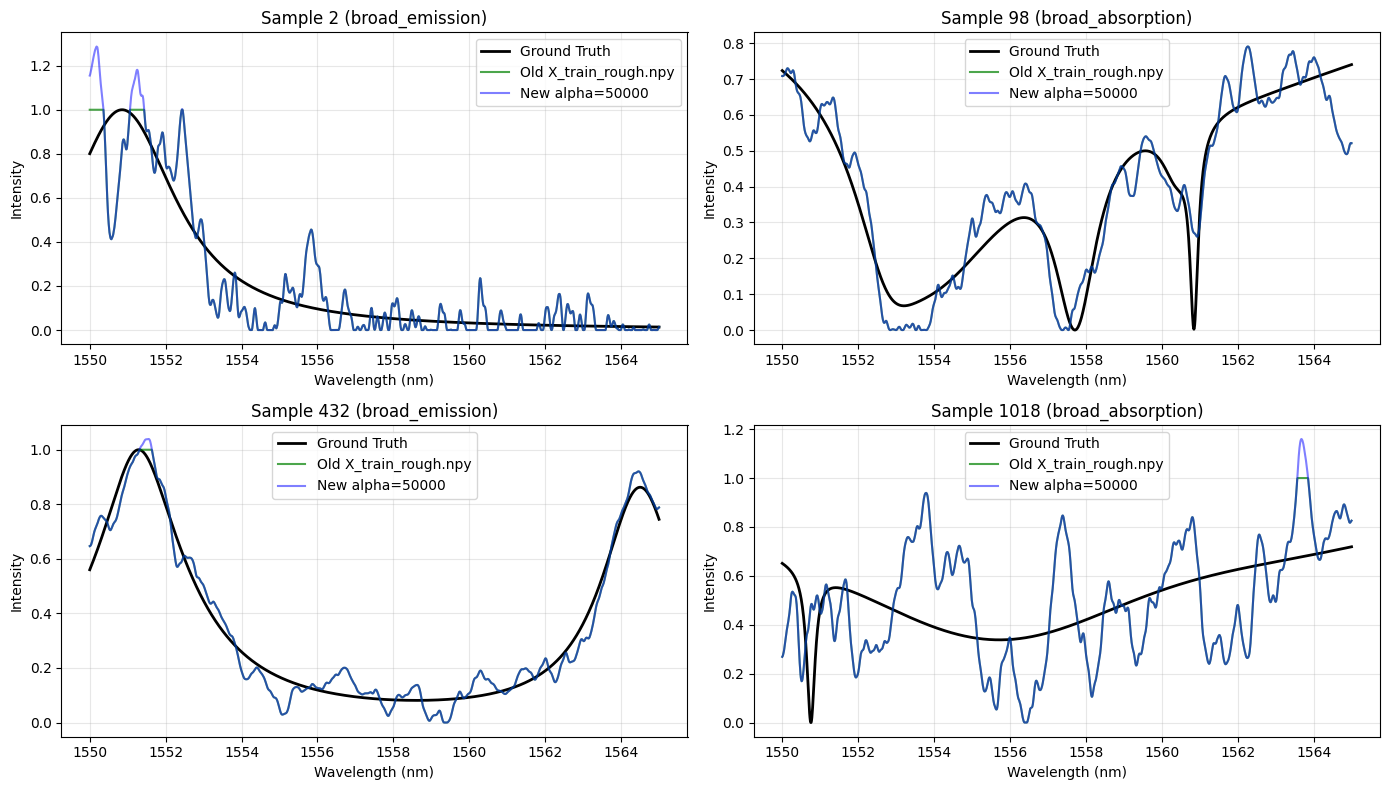

In [8]:
# Sanity check: compare our new alpha=50000 run against the old saved baseline.
# Same broad indices, same ground truth - apples-to-apples.

old_X_rough_full = np.load("data/X_train_rough.npy")  # shape (3000, 1500)
old_X_rough_broad = old_X_rough_full[indices]         # restrict to broad subset
y_broad = y_train_np[indices]

old_mse = np.mean((old_X_rough_broad - y_broad) ** 2)
new_mse = np.mean((X_rough - y_broad) ** 2)

print(f"Old data/X_train_rough.npy (broad subset):  MSE = {old_mse:.6f}")
print(f"  range: [{old_X_rough_broad.min():.3f}, {old_X_rough_broad.max():.3f}]")
print()
print(f"New alpha={ALPHA} generation:                MSE = {new_mse:.6f}")
print(f"  range: [{X_rough.min():.3f}, {X_rough.max():.3f}]")
print()
print(f"If old range is [0, 1] exactly, it was clipped.")

# Side-by-side plots: old (green) vs new (blue) vs ground truth (black)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, j in zip(axes.flatten(), [0, 50, 200, 500]):
    if j >= len(indices):
        continue
    i = indices[j]
    ax.plot(wavelengths, y_train_np[i], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, old_X_rough_broad[j], label="Old X_train_rough.npy", color="green", alpha=0.7)
    ax.plot(wavelengths, X_rough[j], label=f"New alpha={ALPHA}", color="blue", alpha=0.5)
    ax.set_title(f"Sample {i} ({labels_list[i].replace('generate_', '')})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
# Generate EXTRA broad-only data to expand the training set.
# Uses a different seed so the new spectra don't duplicate the original 1479 broad samples.
# Saves to separate files so the original data is untouched.

EXTRA_BROAD_COUNT = 4000
EXTRA_SEED = 84

extra_X_path = "data/X_train_np_broad_extra.npy"
extra_y_path = "data/y_train_np_broad_extra.npy"

if all(os.path.exists(f) for f in [extra_X_path, extra_y_path]):
    print("Extra broad spectra already exist - loading from disk.")
    X_train_np_extra = np.load(extra_X_path)
    y_train_np_extra = np.load(extra_y_path)
else:
    print(f"Generating {EXTRA_BROAD_COUNT} extra broad samples with seed={EXTRA_SEED}...")
    random.seed(EXTRA_SEED)
    np.random.seed(EXTRA_SEED)

    X_extra_list, y_extra_list = [], []
    for _ in range(EXTRA_BROAD_COUNT):
        spectrum_generator = random.choice([generate_broad_emission, generate_broad_absorption])
        spectrum = spectrum_generator(random.randint(1, 10))
        snr_db = random.choice([30, 40, 50])
        measurement = simulate_measurement(spectrum, calibration_matrix, snr_db)
        X_extra_list.append(measurement)
        y_extra_list.append(spectrum)

    X_train_np_extra = np.array(X_extra_list)
    y_train_np_extra = np.array(y_extra_list)

    np.save(extra_X_path, X_train_np_extra)
    np.save(extra_y_path, y_train_np_extra)
    print("Saved.")

print(f"Extra broad measurements:  {X_train_np_extra.shape}")
print(f"Extra broad ground truth:  {y_train_np_extra.shape}")


Generating 4000 extra broad samples with seed=84...
Saved.
Extra broad measurements:  (4000, 25)
Extra broad ground truth:  (4000, 1500)


In [16]:
# NNLS rough drafts for the extra broad samples.
# Uses alpha=50000 + clip to [0,1] to MATCH the original baseline exactly,
# so the extra data is plug-compatible with the existing X_train_rough.npy entries.
# Slow part: ~40 min on 8 cores for 4000 samples.

EXTRA_ALPHA = 50000
extra_rough_path = f"data/X_train_rough_broad_extra_alpha{EXTRA_ALPHA}.npy"

if os.path.exists(extra_rough_path):
    print(f"Extra broad rough drafts already exist - loading from disk.")
    X_train_rough_extra = np.load(extra_rough_path)
else:
    # Build augmented system (same alpha=50000 as the original baseline)
    L_local = build_L(1500)
    T_aug_extra = np.vstack([calibration_matrix, np.sqrt(EXTRA_ALPHA) * L_local])

    print(f"Running NNLS on {len(X_train_np_extra)} extra broad samples (alpha={EXTRA_ALPHA})...")

    def solve_one_clipped(measurement, T_aug):
        y_aug = np.concatenate([measurement, np.zeros(1499)])
        x, _ = nnls(T_aug, y_aug)
        return np.clip(x, 0, 1)  # clip to match the original baseline pipeline

    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(solve_one_clipped)(X_train_np_extra[i], T_aug_extra)
        for i in range(len(X_train_np_extra))
    )
    X_train_rough_extra = np.array(results)

    np.save(extra_rough_path, X_train_rough_extra)
    print(f"Saved {X_train_rough_extra.shape} -> {extra_rough_path}")

# Sanity: input quality of the extra rough drafts vs ground truth
extra_input_mse = np.mean((X_train_rough_extra - y_train_np_extra) ** 2)
print(f"Extra broad rough drafts input MSE: {extra_input_mse:.6f}")
print(f"(Original broad baseline was 0.078262 - should be similar)")


Running NNLS on 4000 extra broad samples (alpha=50000)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   21.3s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   28.7s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   33.8s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   38.0s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   46.1s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   53.3s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1

Saved (4000, 1500) -> data/X_train_rough_broad_extra_alpha50000.npy
Extra broad rough drafts input MSE: 0.082346
(Original broad baseline was 0.078262 - should be similar)
